# 🏠 NYC Airbnb Open Data — Exploratory Data Analysis

## Project Objective
This notebook analyzes the **New York City Airbnb Open Data (2019)** dataset using **Pandas, Matplotlib, and Seaborn**.

### Requirements covered
- Google Colab-ready notebook
- Dataset with more than 10,000 rows and 10 columns
- Data loading, inspection, cleaning, and transformation with Pandas
- Exploratory analysis
- Matplotlib visualizations
- Seaborn statistical visualizations
- Key insights and recommendations

**Dataset:** NYC Airbnb Open Data — 48,895 rows and 16 columns. The dataset is widely available through Kaggle and open repositories. citeturn0search0turn0search2


## 1. Install and Import Libraries

We install the visualization libraries and import the packages required for analysis.

In [16]:
!pip -q install pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Load the Dataset

The CSV is loaded directly from a public GitHub repository containing the same NYC Airbnb dataset. This avoids requiring a Kaggle API key in Colab.

In [17]:
DATA_URL = 'https://raw.githubusercontent.com/TheresaBenny/Data-607/refs/heads/main/AB_NYC_2019.csv'
df = pd.read_csv(DATA_URL)

print(f'Dataset shape: {df.shape}')
df.head()


Dataset shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 3. Dataset Inspection

In [18]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('\nData types:')
print(df.dtypes)

print('\nBasic statistics:')
display(df.describe(include='all').T)


Rows: 48895
Columns: 16

Data types:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


In [4]:
# Check duplicate rows
print('Duplicate rows:', df.duplicated().sum())

# Check missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_percent': missing_pct})
display(missing_report[missing_report['missing_count'] > 0])


Duplicate rows: 0


,missing_count,missing_percent
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03


## 4. Data Cleaning

### Cleaning decisions
- Remove duplicate records.
- Convert `last_review` to a proper datetime column.
- Fill missing `name` and `host_name` with `Unknown`.
- Fill missing `reviews_per_month` with `0` because listings with no reviews do not have a monthly review rate.
- Fill missing `last_review` with the median review date for analysis purposes; the original missingness is also retained through a flag.
- Remove impossible zero-price listings from price-based analysis.
- Create useful derived variables such as `price_per_minimum_night` and `has_reviews`.

In [19]:
df_clean = df.copy()

# Remove duplicates
df_clean = df_clean.drop_duplicates().copy()

# Standardize text columns
text_cols = ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type']
for col in text_cols:
    df_clean[col] = df_clean[col].astype('string').str.strip()

df_clean['name'] = df_clean['name'].fillna('Unknown')
df_clean['host_name'] = df_clean['host_name'].fillna('Unknown')

# Date conversion and missingness flag
df_clean['last_review'] = pd.to_datetime(df_clean['last_review'], errors='coerce')
df_clean['last_review_missing'] = df_clean['last_review'].isna()
median_review_date = df_clean['last_review'].median()
df_clean['last_review'] = df_clean['last_review'].fillna(median_review_date)

# Numeric missing values
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

# Remove invalid prices for price-focused analysis
before = len(df_clean)
df_clean = df_clean[df_clean['price'] > 0].copy()
removed_zero_price = before - len(df_clean)

# Derived columns
df_clean['has_reviews'] = (df_clean['number_of_reviews'] > 0).astype(int)
df_clean['price_per_minimum_night'] = df_clean['price'] / df_clean['minimum_nights'].replace(0, np.nan)
df_clean['price_log'] = np.log1p(df_clean['price'])

print(f'Removed zero/invalid-price listings: {removed_zero_price}')
print(f'Clean dataset shape: {df_clean.shape}')
display(df_clean.head())


Removed zero/invalid-price listings: 11
Clean dataset shape: (48884, 20)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,last_review_missing,has_reviews,price_per_minimum_night,price_log
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,False,1,149.0,5.010635
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,False,1,225.0,5.420535
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,2019-05-19,0.00,1,365,True,0,50.0,5.017280
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,False,1,89.0,4.499810
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,False,1,8.0,4.394449


In [6]:
# Verify cleaning
cleaning_summary = pd.DataFrame({
    'before': [len(df), df.isna().sum().sum(), df.duplicated().sum()],
    'after': [len(df_clean), df_clean.isna().sum().sum(), df_clean.duplicated().sum()]
}, index=['rows', 'total_missing_cells', 'duplicate_rows'])
display(cleaning_summary)

print('Remaining missing values:')
display(df_clean.isna().sum().sort_values(ascending=False).head(10))


,before,after
rows,48895,48884
total_missing_cells,20141,0
duplicate_rows,0,0


Remaining missing values:


id                     0
name                   0
host_id                0
host_name              0
neighbourhood_group    0
neighbourhood          0
latitude               0
longitude              0
room_type              0
price                  0
dtype: int64

## 5. Exploratory Data Analysis — Listings and Prices

In [7]:
borough_summary = (df_clean.groupby('neighbourhood_group')
                   .agg(listings=('id','count'),
                        avg_price=('price','mean'),
                        median_price=('price','median'),
                        avg_reviews=('number_of_reviews','mean'))
                   .sort_values('listings', ascending=False))
display(borough_summary.round(2))


,listings,avg_price,median_price,avg_reviews
neighbourhood_group,,,,
Manhattan,21660,196.88,150.0,20.99
Brooklyn,20095,124.44,90.0,24.20
Queens,5666,99.52,75.0,27.70
Bronx,1090,87.58,65.0,25.98
Staten Island,373,114.81,75.0,30.94


### Question 1: Which boroughs have the most listings?

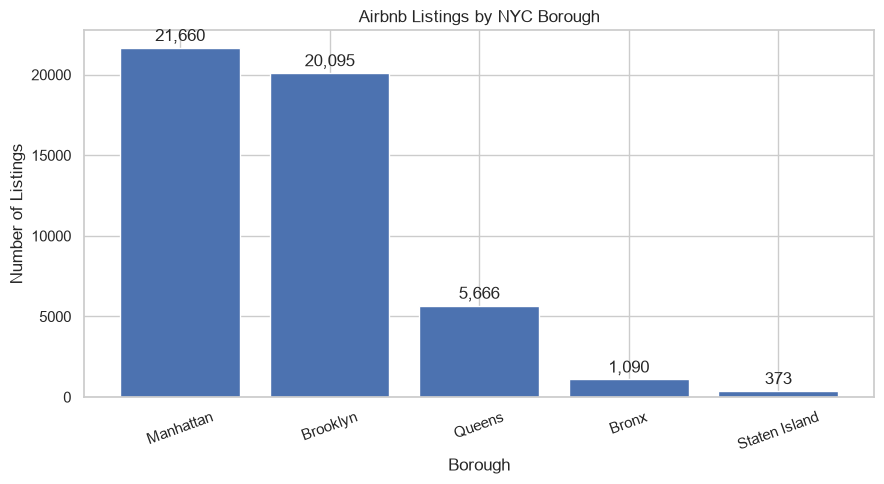

In [8]:
counts = df_clean['neighbourhood_group'].value_counts()

plt.figure(figsize=(9,5))
bars = plt.bar(counts.index, counts.values)
plt.title('Airbnb Listings by NYC Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Listings')
plt.xticks(rotation=20)

for bar, value in zip(bars, counts.values):
    plt.annotate(f'{value:,}', (bar.get_x() + bar.get_width()/2, value),
                 textcoords='offset points', xytext=(0,5), ha='center')
plt.tight_layout()
plt.show()


### Question 2: How is price distributed?

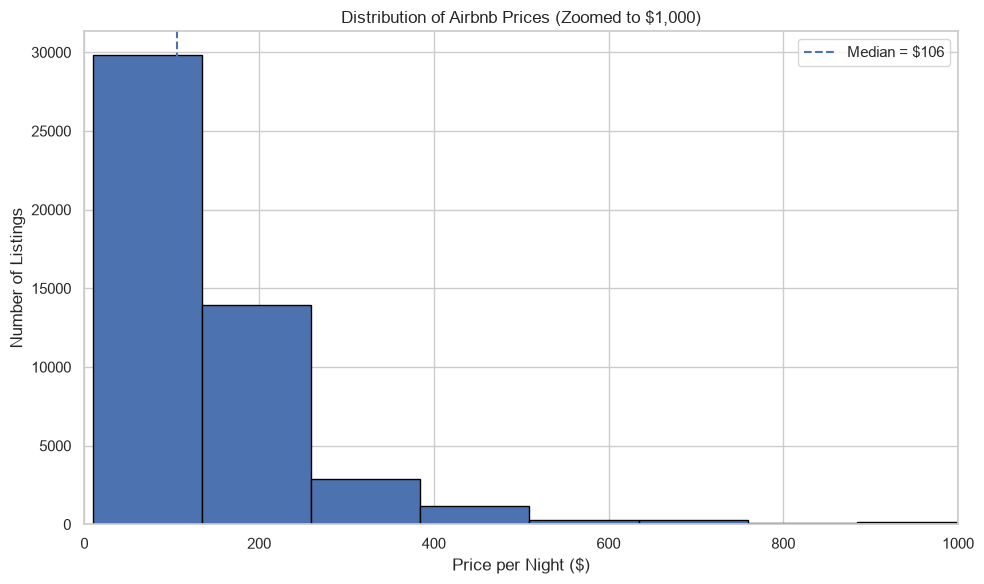

In [9]:
plt.figure(figsize=(10,6))
plt.hist(df_clean['price'], bins=80, edgecolor='black')
plt.xlim(0, 1000)
plt.title('Distribution of Airbnb Prices (Zoomed to $1,000)')
plt.xlabel('Price per Night ($)')
plt.ylabel('Number of Listings')
plt.axvline(df_clean['price'].median(), linestyle='--', label=f"Median = ${df_clean['price'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()


### Question 3: Does room type affect price?

,listings,median_price,avg_price
room_type,,,
Entire home/apt,25407,160.0,211.81
Private room,22319,70.0,89.81
Shared room,1158,45.0,70.25


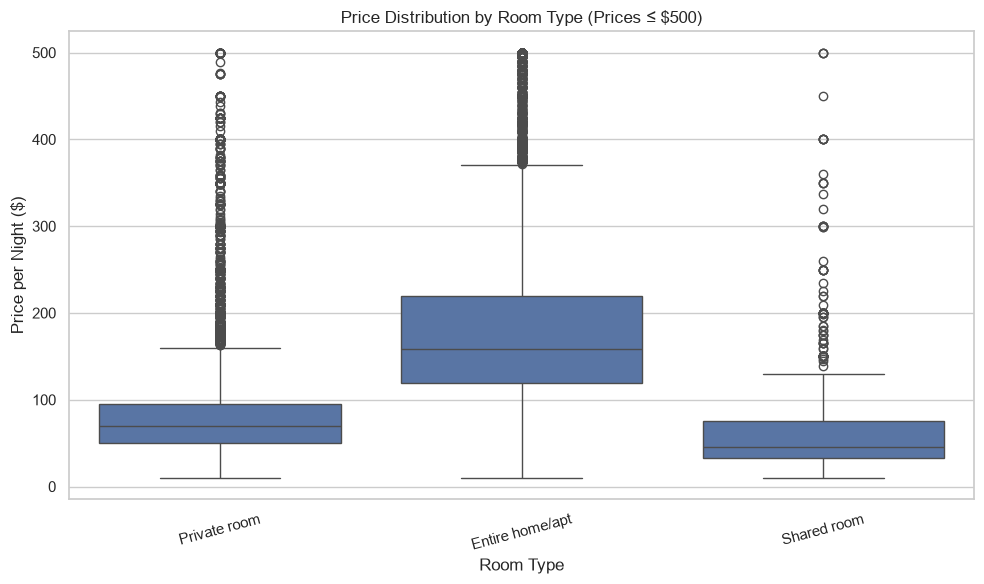

In [10]:
room_summary = (df_clean.groupby('room_type')
                .agg(listings=('id','count'), median_price=('price','median'), avg_price=('price','mean'))
                .sort_values('median_price', ascending=False))
display(room_summary.round(2))

plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean[df_clean['price'] <= 500], x='room_type', y='price')
plt.title('Price Distribution by Room Type (Prices ≤ $500)')
plt.xlabel('Room Type')
plt.ylabel('Price per Night ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 6. Seaborn Statistical Analysis

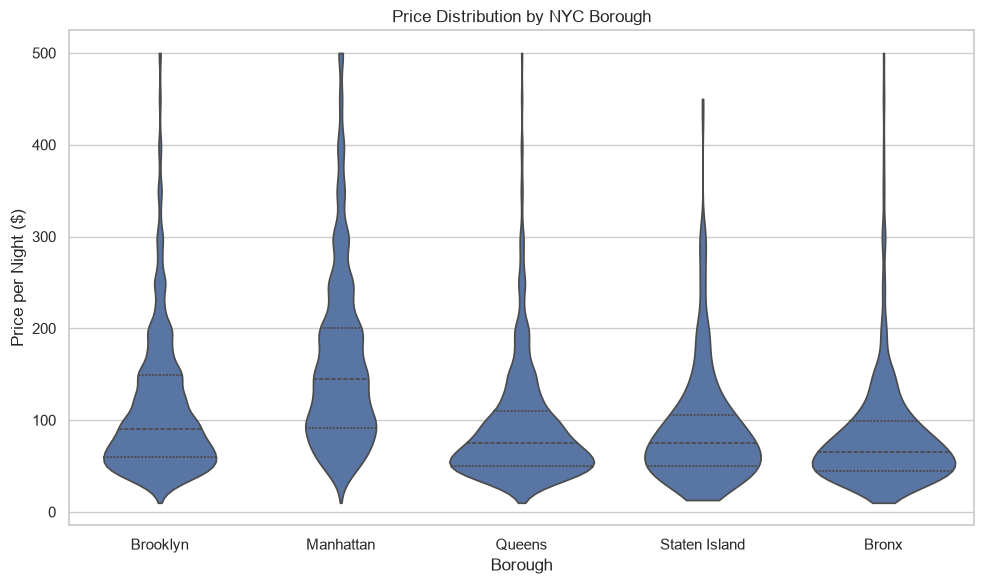

In [11]:
# Price by borough using a violin plot
plt.figure(figsize=(10,6))
plot_df = df_clean[df_clean['price'] <= 500]
sns.violinplot(data=plot_df, x='neighbourhood_group', y='price', inner='quartile', cut=0)
plt.title('Price Distribution by NYC Borough')
plt.xlabel('Borough')
plt.ylabel('Price per Night ($)')
plt.tight_layout()
plt.show()


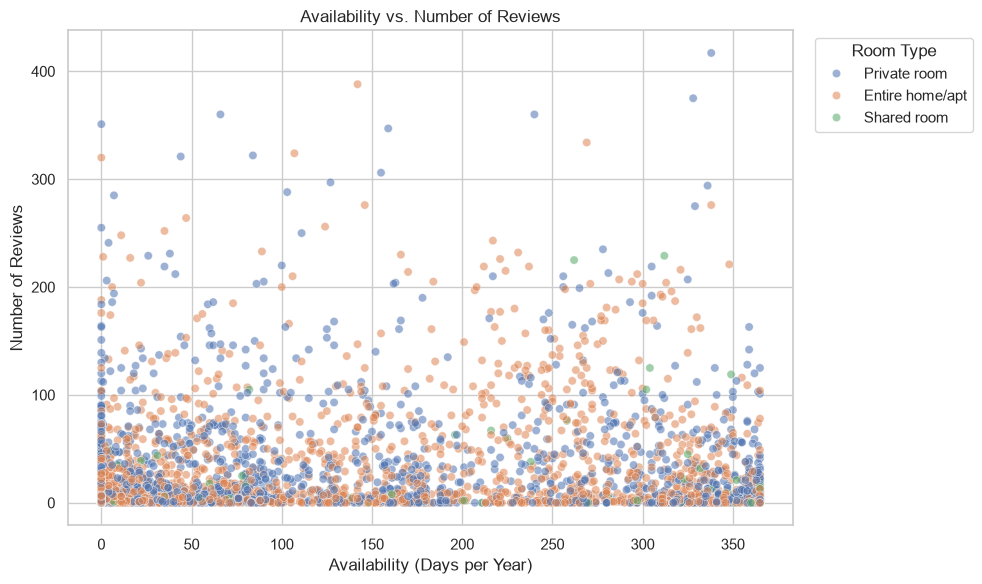

In [12]:
# Relationship between availability and reviews
sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)
plt.figure(figsize=(10,6))
sns.scatterplot(data=sample, x='availability_365', y='number_of_reviews',
                hue='room_type', alpha=0.55)
plt.title('Availability vs. Number of Reviews')
plt.xlabel('Availability (Days per Year)')
plt.ylabel('Number of Reviews')
plt.legend(title='Room Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Correlation Analysis

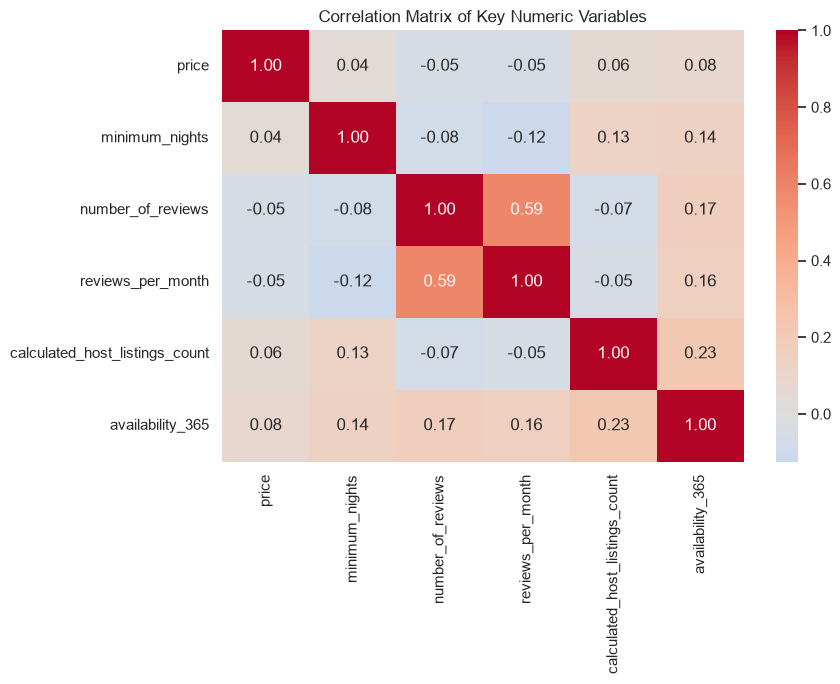

In [13]:
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                'calculated_host_listings_count', 'availability_365']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Key Numeric Variables')
plt.tight_layout()
plt.show()


## 7. Neighborhood Analysis

,listings,median_price,avg_price
neighbourhood,,,
Williamsburg,3919,105.0,143.84
Bedford-Stuyvesant,3710,80.0,107.79
Harlem,2658,89.0,118.97
Bushwick,2462,65.0,84.90
Upper West Side,1971,150.0,210.92
Hell's Kitchen,1958,168.0,204.79
East Village,1853,150.0,186.08
Upper East Side,1798,149.0,188.95
Crown Heights,1564,85.0,112.48


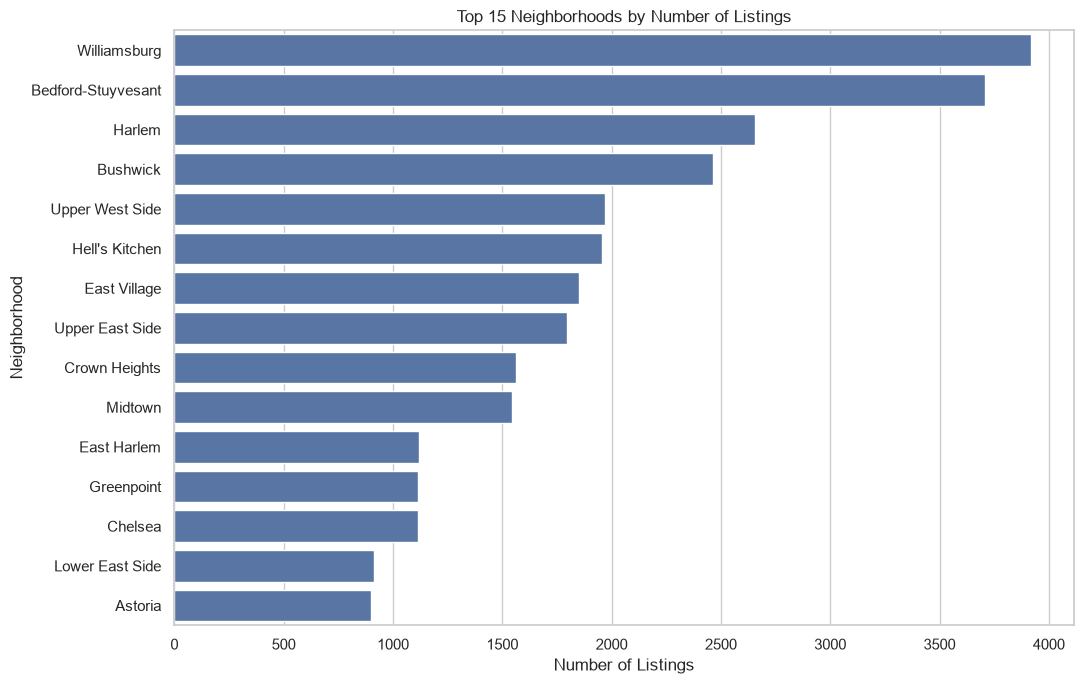

In [14]:
top_neighbourhoods = (df_clean.groupby('neighbourhood')
                      .agg(listings=('id','count'), median_price=('price','median'), avg_price=('price','mean'))
                      .sort_values('listings', ascending=False)
                      .head(15))
display(top_neighbourhoods.round(2))

plt.figure(figsize=(11,7))
sns.barplot(data=top_neighbourhoods.reset_index(), y='neighbourhood', x='listings', orient='h')
plt.title('Top 15 Neighborhoods by Number of Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()


## 8. Additional Business-Oriented Analysis

In [15]:
# Most reviewed listings
top_reviewed = df_clean.nlargest(10, 'number_of_reviews')[
    ['name','neighbourhood_group','neighbourhood','room_type','price','number_of_reviews','availability_365']
]
display(top_reviewed)

# Hosts with the largest number of listings
top_hosts = (df_clean.groupby(['host_id','host_name'])
             .size().reset_index(name='listing_count')
             .sort_values('listing_count', ascending=False).head(10))
display(top_hosts)


,name,neighbourhood_group,neighbourhood,room_type,price,number_of_reviews,availability_365
11759,Room near JFK Queen Bed,Queens,Jamaica,Private room,47,629,333
2031,Great Bedroom in Manhattan,Manhattan,Harlem,Private room,49,607,293
2030,Beautiful Bedroom in Manhattan,Manhattan,Harlem,Private room,49,597,342
2015,Private Bedroom in Manhattan,Manhattan,Harlem,Private room,49,594,339
13495,Room Near JFK Twin Beds,Queens,Jamaica,Private room,47,576,173
10623,Steps away from Laguardia airport,Queens,East Elmhurst,Private room,46,543,163
1879,Manhattan Lux Loft.Like.Love.Lots.Look !,Manhattan,Lower East Side,Private room,99,540,179
20403,Cozy Room Family Home LGA Airport NO CLEANING FEE,Queens,East Elmhurst,Private room,48,510,341
4870,Private brownstone studio Brooklyn,Brooklyn,Park Slope,Entire home/apt,160,488,269
471,LG Private Room/Family Friendly,Brooklyn,Bushwick,Private room,60,480,0


,host_id,host_name,listing_count
34644,219517861,Sonder (NYC),327
29405,107434423,Blueground,232
19572,30283594,Kara,121
31077,137358866,Kazuya,103
14434,16098958,Jeremy & Laura,96
12805,12243051,Sonder,96
25660,61391963,Corporate Housing,91
17089,22541573,Ken,87
33866,200380610,Pranjal,65
9732,7503643,Vida,52


## 9. Key Insights and Observations

The following conclusions should be interpreted from the computed tables and charts above:

1. **Listing concentration:** Airbnb supply is not evenly distributed across NYC boroughs; a small number of boroughs account for a large share of listings.
2. **Price is highly right-skewed:** Most listings are concentrated at relatively moderate nightly prices, while a small number of luxury listings create a long upper tail.
3. **Room type matters:** Entire homes/apartments generally command higher prices than private rooms, while shared rooms tend to be the lowest-priced option.
4. **Location matters:** Median prices differ substantially between boroughs and neighborhoods, indicating that geography is an important pricing factor.
5. **Reviews and availability are not interchangeable:** A listing can have high availability but few reviews, while highly reviewed listings may have lower availability because of stronger demand.
6. **Outliers matter:** Extremely high prices and unusually large minimum-night requirements can distort averages, so medians and distribution plots are useful alongside means.


## 10. Recommendations

### For Airbnb hosts
- Use neighborhood and room-type benchmarks when setting nightly prices.
- Monitor availability and review volume together rather than using either metric alone.
- Investigate local competitors before making large pricing changes.
- Consider dynamic pricing around high-demand periods.

### For guests
- Compare median prices within the same neighborhood rather than comparing city-wide averages.
- Consider private rooms when the primary goal is lower cost.
- Check minimum-night requirements because a low nightly price may not imply a low total trip cost.

### For analysts/business teams
- Build a predictive pricing model using location, room type, reviews, availability, and minimum nights.
- Add time-based features if newer listing snapshots are available.
- Treat extreme price observations carefully and report both mean and median metrics.


## 11. Final Conclusion

This project demonstrates a complete exploratory data analysis workflow using **Pandas, Matplotlib, and Seaborn**. The NYC Airbnb dataset satisfies the assignment requirements with **48,895 observations and 16 original columns**. The analysis covered data quality checks, missing-value treatment, duplicate handling, feature creation, descriptive statistics, distribution analysis, categorical comparisons, correlation analysis, and business-oriented insights.

The most important takeaway is that **Airbnb pricing is strongly associated with listing characteristics and location**, and the distribution is highly skewed. Therefore, median-based comparisons, neighborhood-level analysis, and statistical visualizations provide a more reliable picture than relying only on city-wide averages.

### Next steps
- Build a machine-learning model to predict listing price.
- Perform outlier detection using IQR or robust statistical methods.
- Add geospatial analysis using latitude and longitude.
- Compare listing behavior across multiple years if newer snapshots are available.


## Dataset Reference

The NYC Airbnb Open Data is a public dataset commonly distributed through Kaggle and open repositories. Public documentation confirms the dataset contains **48,895 rows and 16 columns**. citeturn0search2turn0search8
